### Exercise 1 — Feature Importance

Feature importance tells us how much each feature contributes to the decisions made by the Decision Tree. In scikit-learn, the `feature_importances_` attribute gives the importance of every feature. We can display these values and visualize them using a horizontal bar chart.

The most important feature can be compared with the feature used at the root of the Decision Tree in Task 4. The root feature is the first feature used to split the data, while feature importance considers the contribution of a feature across the whole tree.


In [39]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Breast Cancer dataset
cancer = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df['target'] = cancer.target

print(df.shape)

(569, 31)


In [40]:
print(df['target'].value_counts())

print(cancer.target_names)

print(df.isnull().sum().sum())

target
1    357
0    212
Name: count, dtype: int64
['malignant' 'benign']
0


### Exercise 2 — A Different Dataset

The Wine dataset is a multiclass classification dataset containing three different wine classes. A Decision Tree Classifier will be trained on this dataset, and its depth, number of leaves, and test accuracy will be reported.


In [41]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (455, 30)  Test: (114, 30)


### Exercise 3 — max_leaf_nodes

The `max_leaf_nodes` parameter limits the maximum number of leaf nodes in a Decision Tree. In this exercise, the tree is retrained with a maximum of 8 leaf nodes and its test accuracy is compared with the pre-pruned tree from Task 5.


In [42]:
from sklearn.tree import DecisionTreeClassifier

tree_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=1
)

tree_entropy.fit(X_train, y_train)

print('Entropy tree depth:',
      tree_entropy.get_depth(),
      ' leaves:',
      tree_entropy.get_n_leaves())

print('Train acc:',
      tree_entropy.score(X_train, y_train))

print('Test acc:',
      tree_entropy.score(X_test, y_test))

Entropy tree depth: 6  leaves: 15
Train acc: 1.0
Test acc: 0.9649122807017544


In [43]:
tree_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=1
)

tree_gini.fit(X_train, y_train)

print('Gini tree depth:',
      tree_gini.get_depth(),
      ' leaves:',
      tree_gini.get_n_leaves())

print('Train acc:',
      tree_gini.score(X_train, y_train))

print('Test acc:',
      tree_gini.score(X_test, y_test))

Gini tree depth: 8  leaves: 18
Train acc: 1.0
Test acc: 0.9649122807017544


### Exercise 4 — Comparing Pruning Paths

Cost-complexity pruning uses `ccp_alpha` to control the complexity of a Decision Tree. A larger `ccp_alpha` applies stronger pruning, which generally produces a smaller tree. We will compare the number of leaves and test accuracy for different values of `ccp_alpha`.


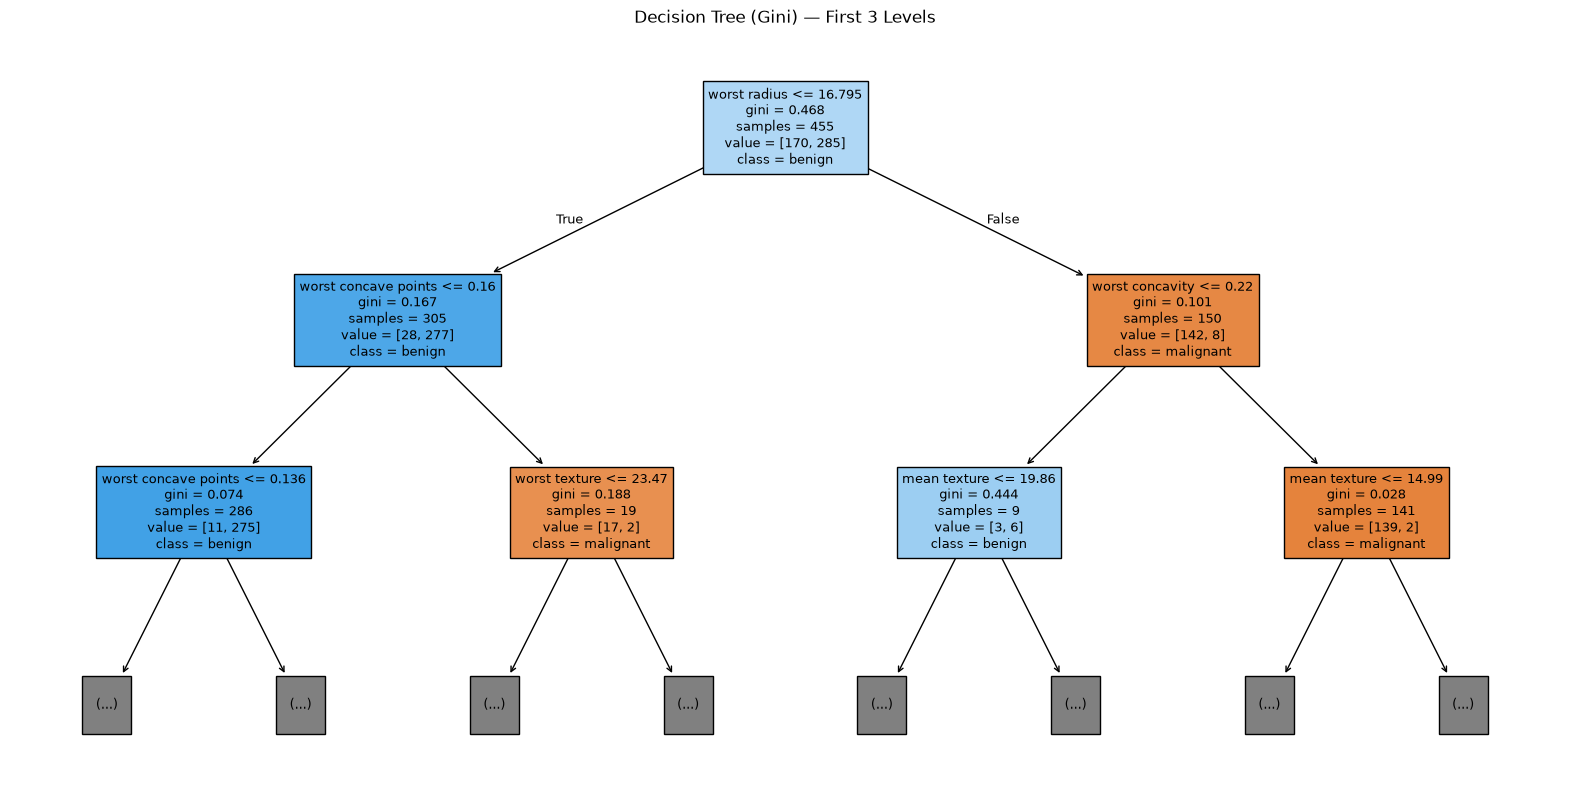

In [44]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    tree_gini,
    max_depth=2,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names,
    filled=True,
    fontsize=9
)

plt.title('Decision Tree (Gini) — First 3 Levels')
plt.show()

In [45]:
root_feature = cancer.feature_names[tree_gini.tree_.feature[0]]

print('Root split feature:', root_feature)

print('Root split threshold:',
      tree_gini.tree_.threshold[0])

Root split feature: worst radius
Root split threshold: 16.795000076293945


### Exercise 5 — Regression Trees

A Decision Tree can also be used for regression problems. Instead of predicting a class, a Regression Tree predicts a continuous numerical value. Here, a `DecisionTreeRegressor` with `max_depth=4` is trained on the California Housing dataset and evaluated using RMSE and R².


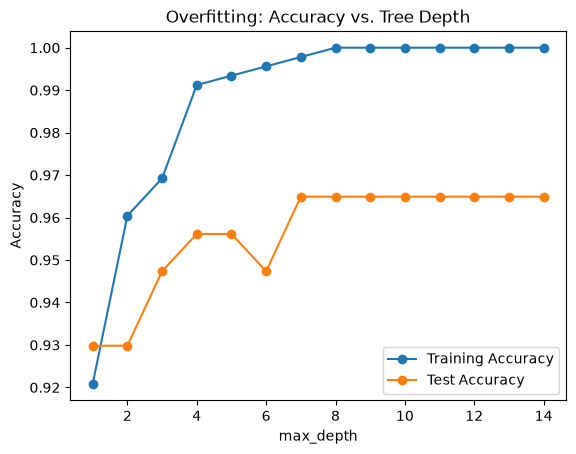

In [46]:
depths = range(1, 15)

train_acc = []
test_acc = []

for d in depths:
    t = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        random_state=1
    )

    t.fit(X_train, y_train)

    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.plot(depths, train_acc, marker='o', label='Training Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()

plt.title('Overfitting: Accuracy vs. Tree Depth')
plt.show()

In [47]:
pruned_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_leaf=5,
    random_state=1
)

pruned_tree.fit(X_train, y_train)

print('Pre-pruned depth:',
      pruned_tree.get_depth(),
      ' leaves:',
      pruned_tree.get_n_leaves())

print('Train acc:',
      pruned_tree.score(X_train, y_train))

print('Test acc:',
      pruned_tree.score(X_test, y_test))

Pre-pruned depth: 3  leaves: 7
Train acc: 0.9604395604395605
Test acc: 0.9298245614035088


In [48]:
from sklearn.model_selection import cross_val_score

path = tree_gini.cost_complexity_pruning_path(X_train, y_train)

alphas = path.ccp_alphas

print('Number of candidate alphas:', len(alphas))

Number of candidate alphas: 12


In [49]:
cv_scores = []

for alpha in alphas:
    t = DecisionTreeClassifier(
        criterion='gini',
        random_state=1,
        ccp_alpha=alpha
    )

    scores = cross_val_score(
        t,
        X_train,
        y_train,
        cv=5
    )

    cv_scores.append(scores.mean())

best_alpha = alphas[np.argmax(cv_scores)]

print('Best alpha:', best_alpha)

Best alpha: 0.01583165770399813


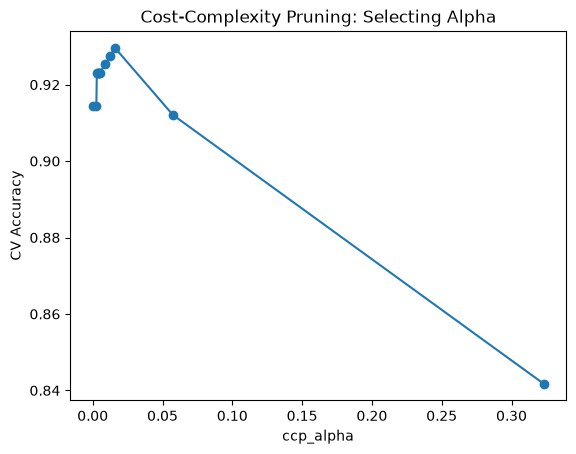

In [50]:
plt.plot(alphas, cv_scores, marker='o')

plt.xlabel('ccp_alpha')
plt.ylabel('CV Accuracy')

plt.title('Cost-Complexity Pruning: Selecting Alpha')

plt.show()

In [51]:
final_tree = DecisionTreeClassifier(
    criterion='gini',
    random_state=1,
    ccp_alpha=best_alpha
)

final_tree.fit(X_train, y_train)

print('Final tree depth:',
      final_tree.get_depth(),
      ' leaves:',
      final_tree.get_n_leaves())

print('Final test accuracy:',
      final_tree.score(X_test, y_test))

Final tree depth: 2  leaves: 3
Final test accuracy: 0.9385964912280702


### Exercise 6 — Mini-Pipeline

A scikit-learn Pipeline combines model-processing steps into a single object. Decision Trees do not normally require feature scaling, so the tuned Decision Tree can be placed directly inside the Pipeline.


In [52]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print('--- Unpruned Decision Tree (Gini) ---')

preds_unpruned = tree_gini.predict(X_test)

print(classification_report(
    y_test,
    preds_unpruned,
    target_names=cancer.target_names
))


print('--- Pruned Decision Tree (cost-complexity) ---')

preds_pruned = final_tree.predict(X_test)

print(classification_report(
    y_test,
    preds_pruned,
    target_names=cancer.target_names
))

--- Unpruned Decision Tree (Gini) ---
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

--- Pruned Decision Tree (cost-complexity) ---
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



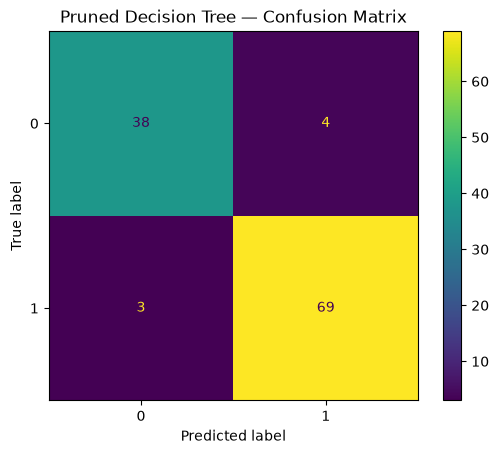

In [53]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds_pruned
)

plt.title('Pruned Decision Tree — Confusion Matrix')
plt.show()

In [54]:
print("Unpruned Decision Tree Accuracy:",
      tree_gini.score(X_test, y_test))

print("Pruned Decision Tree Accuracy:",
      final_tree.score(X_test, y_test))

Unpruned Decision Tree Accuracy: 0.9649122807017544
Pruned Decision Tree Accuracy: 0.9385964912280702


### Exercise 7 — Capstone Challenge

In this challenge, three Decision Trees are trained using very small, medium, and very large `ccp_alpha` values. The purpose is to observe how pruning affects model complexity, training accuracy, and test accuracy. A very small alpha produces little pruning, while a larger alpha produces stronger pruning.


In [55]:
# Capstone Challenge
# Three different ccp_alpha values

alpha_values = {
    "Very Small": 0.0001,
    "Medium": 0.01,
    "Very Large": 0.1
}

results = []

for name, alpha in alpha_values.items():

    tree = DecisionTreeClassifier(
        criterion='gini',
        random_state=1,
        ccp_alpha=alpha
    )

    tree.fit(X_train, y_train)

    results.append({
        "ccp_alpha": alpha,
        "Category": name,
        "Depth": tree.get_depth(),
        "Leaves": tree.get_n_leaves(),
        "Train Accuracy": tree.score(X_train, y_train),
        "Test Accuracy": tree.score(X_test, y_test)
    })

capstone_results = pd.DataFrame(results)

print(capstone_results)

   ccp_alpha    Category  Depth  Leaves  Train Accuracy  Test Accuracy
0     0.0001  Very Small      8      18        1.000000       0.964912
1     0.0100      Medium      4       6        0.973626       0.938596
2     0.1000  Very Large      1       2        0.920879       0.929825


In [56]:
capstone_results["Train Accuracy"] = (
    capstone_results["Train Accuracy"] * 100
).round(2)

capstone_results["Test Accuracy"] = (
    capstone_results["Test Accuracy"] * 100
).round(2)

capstone_results

,ccp_alpha,Category,Depth,Leaves,Train Accuracy,Test Accuracy
0,0.0001,Very Small,8,18,100.00,96.49
1,0.0100,Medium,4,6,97.36,93.86
2,0.1000,Very Large,1,2,92.09,92.98
